# Methods in Data Science - Homework 2 - Wilmington College

**Chapter 3: Exercises 8, 9, 10 and 15**

### Exercise 8
This question involves the use of simple linear regression on the `Auto` data set.
- (a) Use the `sm.OLS()` function to perform a simple linear regression
with `mpg` as the response and `horsepower` as the predictor. Use
the summarize() function to print the results. Comment on the
output. For example:
    - i. Is there a relationship between the predictor and the re-
sponse?
    - ii. How strong is the relationship between the predictor and
the response?
    - iii. Is the relationship between the predictor and the response
positive or negative?
    - iv. What is the predicted `mpg` associated with a `horsepower` of
98? What are the associated 95 % confidence and prediction
intervals?
- (b) Plot the response and the predictor in a new set of axes `ax`. Use
the `ax.axline()` method or the `abline()` function defined in the
lab to display the least squares regression line.
- (c) Produce some of diagnostic plots of the least squares regression
fit as described in the lab. Comment on any problems you see
with the fit.

In [41]:
#--------------Solution----------------#
#Question a 
import pandas as pd 
import statsmodels.api as sm 
import numpy as np
import matplotlib.pyplot as plt
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
print("All libraries imported successfully")

# load the dataset and treat '?' as missing values
auto = pd.read_csv("/workspaces/Methods_In_Data_Science/Auto.csv", na_values="?")
auto = auto.dropna(subset=["horsepower", "mpg"]).copy()
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")
auto["mpg"] = pd.to_numeric(auto["mpg"], errors="coerce")

# defining predictor and response 
x = auto["horsepower"]
y = auto["mpg"]
# adding intercept 
x = sm.add_constant(x)
# fit model 
model = sm.OLS(y, x).fit()
print(model.summary())

# predicted mpg at horsepower = 98 with 95% confidence and prediction intervals
x_new = pd.DataFrame({"const": [1.0], "horsepower": [98]})
pred = model.get_prediction(x_new)
print(pred.summary_frame(alpha=0.05))
print("The p value for the horsepower coefficient is less than 0.05, indicating that it is statistically significant in predicting mpg. The R-squared value of the model is 0.6059, suggesting that a greater percentage of the variability in mpg can be explained by horsepower.")

All libraries imported successfully
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           7.03e-81
Time:                        14:46:16   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39

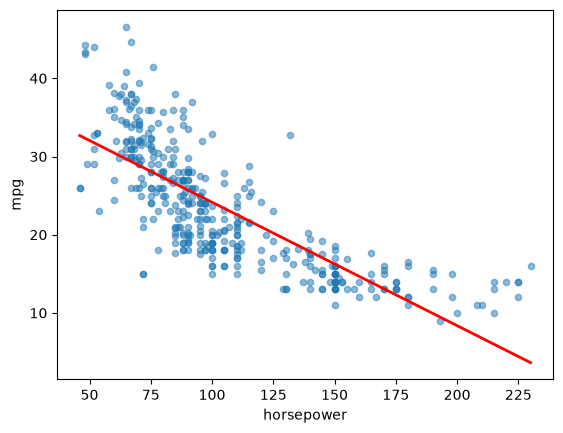

In [42]:
###(b)Plot the response and the predictor in a new set of axes `ax`. Use
#the `ax.axline()` method or the `abline()` function defined in the
#lab to display the least squares regression line. 

# convert horsepower to numeric before plotting/regression
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")
auto["mpg"] = pd.to_numeric(auto["mpg"], errors="coerce")
auto = auto.dropna(subset=["horsepower", "mpg"]).copy()

# fit the model again on the cleaned data
x = sm.add_constant(auto["horsepower"])
y = auto["mpg"]
model = sm.OLS(y, x).fit()

# abline function

def abline(ax, slope, intercept, **kwargs):
    xvals = np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 100)
    yvals = intercept + slope * xvals
    ax.plot(xvals, yvals, **kwargs)

ax = auto.plot.scatter("horsepower", "mpg", alpha=0.5)
abline(ax, model.params["horsepower"], model.params["const"], color="red", linewidth=2)
plt.show()

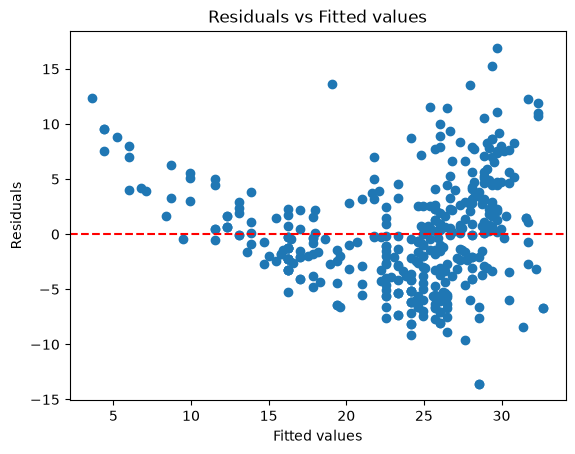

The residuals formed a straight line around 0, indicating that the model is good fit. However, there seems to be some heteroscedasticity in the residuals.


In [43]:
#(c)Produce some of diagnostic plots of the least squares regression
#fit as described in the lab. Comment on any problems you see
#with the fit.
x = sm.add_constant(auto["horsepower"])
y = auto["mpg"]
model = sm.OLS(y, x).fit()

# Create diagnostic plots
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.show()
print('The residuals formed a straight line around 0, indicating that the model is good fit. ' \
'However, there seems to be some heteroscedasticity in the residuals.')



### Exercise 9
This question involves the use of multiple linear regression on the
`Auto` data set.
- (a) Produce a scatterplot matrix which includes all of the variables
in the data set.
- (b) Compute the matrix of correlations between the variables using
the `DataFrame.corr()` method.
- (c) Use the `sm.OLS()` function to perform a multiple linear regression
with `mpg` as the response and all other variables except name as
the predictors. Use the `summarize()` function to print the results.
Comment on the output. For instance:
    - i. Is there a relationship between the predictors and the response? Use the `anova_lm()` function from `statsmodels` to
answer this question.
    - ii. Which predictors appear to have a statistically significant
relationship to the response?
    - iii. What does the coefficient for the `year` variable suggest?
- (d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?
- (e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?
- (f) Try a few different transformations of the variables, such as
$log(X), \sqrt(X), X^2$. Comment on your findings.

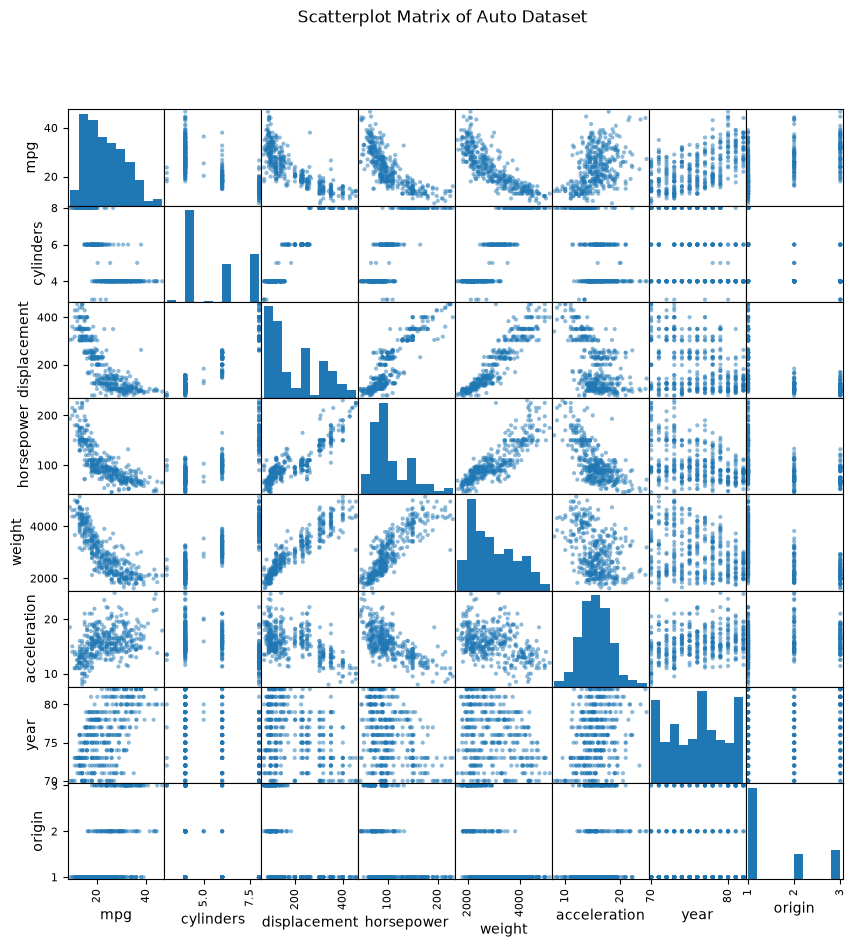

In [44]:
#--------------Solution----------------#
#(a)Produce a scatterplot matrix which includes all of the variables in the data set 
scattermatrix = pd.plotting.scatter_matrix(auto, alpha=0.5, figsize=(10, 10))
plt.suptitle('Scatterplot Matrix of Auto Dataset')
plt.show()





In [45]:
#(b) Compute the matrix of correlations between the variables using the `DataFrame.corr()`method 
df = pd.DataFrame(auto)
df_numeric = df.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()
print("Correlation matrix:\n", correlation_matrix)


Correlation matrix:
                    mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000 

In [46]:
#(c) Use the `sm.OLS()` function to perform a multiple linear regression
#with `mpg` as the response and all other variables except name as
#the predictors. Use the `summarize()` function to print the results.
#Comment on the output. 
x = auto.drop(columns=["mpg", "name"])
y = auto["mpg"]
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          2.04e-139
Time:                        14:46:18   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

Const, year, and origin have a strong relationship to the response since the p value is less that 0.05
The coeff for the year suggest that mpg increases by 0.7508 every year 

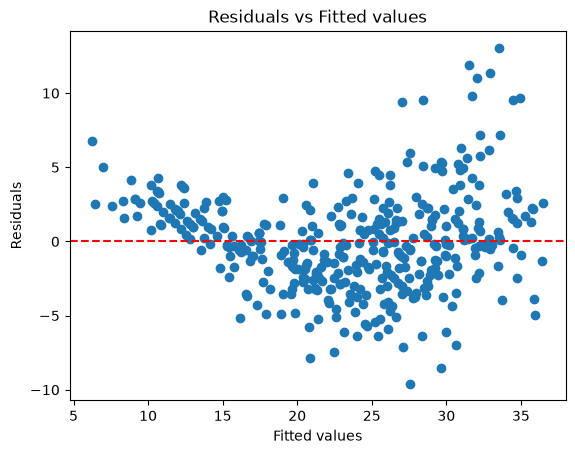

In [47]:
#(d) Produce some of diagnostic plots of the linear regression fit as
#described in the lab. Comment on any problems you see with the
#fit. Do the residual plots suggest any unusually large outliers?
#Does the leverage plot identify any observations with unusually
#high leverage?
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.show()

The diagonostic plot shows that the model is a good fit, there are also some outliers, and they can sometimes affect the model


In [48]:
#(e) Fit some models with interactions as described in the lab. Do
#any interactions appear to be statistically significant?
model_interaction = sm.OLS(y, x.assign(weight_displacement=x["weight"]*x["displacement"])).fit()
print(model_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     291.1
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.27e-157
Time:                        14:46:19   Log-Likelihood:                -977.57
No. Observations:                 392   AIC:                             1973.
Df Residuals:                     383   BIC:                             2009.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -5.3892    

### Exercise 10. 
This question should be answered using the Carseats data set.
- (a) Fit a multiple regression model to predict Sales using Price,
Urban, and US.
- (b) Provide an interpretation of each coefficient in the model. Be
careful—some of the variables in the model are qualitative!
- (c) Write out the model in equation form, being careful to handle
the qualitative variables properly.
- (d) For which of the predictors can you reject the null hypothesis
$H_0 : β_j = 0$?
- (e) On the basis of your response to the previous question, fit a
smaller model that only uses the predictors for which there is
evidence of association with the outcome.
- (f) How well do the models in (a) and (e) fit the data?
- (g) Using the model from (e), obtain 95 % confidence intervals for
the coefficient(s).
- (h) Is there evidence of outliers or high leverage observations in the
model from (e)?

In [49]:
#--------------Solution----------------#
carseats = pd.read_csv("/workspaces/Methods_In_Data_Science/Carseats.csv")

#(a)Fit a multiple regression model to predict Sales using Price,Urban, and US.
carseats["Urban"] = carseats["Urban"].astype("category")
carseats["US"] = carseats["US"].astype("category")
X = MS(["Price", "Urban", "US"]).fit_transform(carseats)
y = carseats["Sales"]

model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)



,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


#(b) Provide an interpretation of each coefficient in the model. Be
careful—some of the variables in the model are qualitative
1)The coefficient for price means that for for every 1 unit increase in Price, the predicted response decreases by 0.0545 units

2)The coefficient for Urban is a dummy variable, meaning observations in urban areas have a response that is 0.0219 units lower than those in non-urban areas


3)US is also a dummy variable, meaning observations in US are predicted to have a response 1.2006 units higher than those outside the US 
 

#(c) Write out the model in equation form, being careful to handle
the qualitative variables properly.
Y = 13.0435 -0.0545(Price) -0.0219(Urban[Yes]) + 1.2006(US[Yes])

#(d) For which of the predictors can you reject the null hypothesis $H_0 : β_j = 0$?

We can reject hypothesis for Price and US because the p values are less that 0.05, but not for urban


In [50]:
#(e) On the basis of your response to the previous question, fit a
#smaller model that only uses the predictors for which there is
#evidence of association with the outcome.
x = carseats.columns.drop(['Price', 'US'])
y = carseats['Sales']
x = ["Price", "US"]
X2 = MS(x).fit_transform(carseats)
model2 = sm.OLS(y, X2)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US[Yes],1.1996,0.258,4.641,0.0


In [51]:
#f How well do the models in(a) and (e) fit the data 
model1_r2 = results1.rsquared
model2_r2 = results2.rsquared
print(f"Model 1 R-squared: {model1_r2:.4f}")
print(f"Model 2 R-squared: {model2_r2:.4f}")


Model 1 R-squared: 0.2393
Model 2 R-squared: 0.2393


#(f) How well do the models in (a) and (e) fit the data?

1) Since the R squared are identical, the simpler model with only Price and US is preferred because it achieves the same fit with fewer predictors 

In [52]:
#(g) Using the model from (e), obtain 95 % confidence intervals for the coefficient(s).
results2.conf_int(alpha=0.05)


,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


In [53]:
#(h) Is there evidence of outliers or high leverage observations in the model from (e)?
influence = results2.get_influence()
studentized_residuals = influence.resid_studentized_external
print("Studentized residuals:\n", studentized_residuals)



Studentized residuals:
 [ 0.73272036  0.61426597  0.07632636 -0.62739878 -0.77520951  0.20434493
 -0.20995228  1.69061166  0.107354   -1.13061035  0.09218027  1.15841442
 -0.66749367  0.57472779  1.36801969  1.43696846  0.21990458  2.11850399
  1.38206303  0.44238091 -0.27727761  1.56011879 -0.17593334 -0.49646209
  0.83779241  2.59965175  0.50130855 -0.7847249  -2.43374524 -0.35023388
  2.19494228  0.46884628 -0.22999364  0.61346058 -1.86762006  0.84016267
  0.53089344 -1.33550038 -0.35900097 -0.92471732 -1.66911248  0.68423558
 -0.53499315 -1.141512   -1.99572922 -0.94024917  0.82456744 -1.12503396
 -1.54050468  2.33437613 -2.83584311 -1.10872074  0.28669787 -0.33542101
 -0.60331877  0.41029521  1.40881123 -2.34878813 -1.29975797 -0.65395634
  0.32033003  0.04802646 -2.10592255 -0.10468943 -0.31005893 -0.47020847
  0.31564984  0.42336149  2.64236365  0.14314528  0.25260012  0.17924489
 -0.48370598  1.64546635 -0.25207254 -0.27129704  0.09081649 -0.68316423
 -0.77238375  0.41144916 -0

### Exercis 15

This problem involves the `Boston` data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.
- (a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.
- (b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis $H_0 : \beta_j = 0$?
- (c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.
- (d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
$$Y= \beta_0 + \beta_1X + β2X^2 + \beta_3X^3 + \epsilon.$$

In [54]:
#--------------Solution----------------#
boston = pd.read_csv("/workspaces/Methods_In_Data_Science/Boston.csv")
boston 

###(a) For each predictor, fit a simple linear regression model to predict
#the response. Describe your results. In which of the models is
#there a statistically significant association between the predictor
#and the response? Create some plots to back up your assertions.

#Identifying predictors and response variable
predictors = ['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','lstat']
results = {}
for var in predictors:
    x = sm.add_constant(boston[var])
    y = boston['medv']
    model = sm.OLS(y, x).fit()
    results[var] = model
    print(f"Results for predictor: {var}")
    print(model.summary())
    print("\n")


Results for predictor: crim
                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     89.49
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.17e-19
Time:                        14:46:19   Log-Likelihood:                -1798.9
No. Observations:                 506   AIC:                             3602.
Df Residuals:                     504   BIC:                             3610.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.0331   

#The model that is statistically significant 
The predictors all appear to have p values less than 0.05 except for age and indus whose p value is greater that 0.05, the R squared values also less than 0.50 for majority of predictors. 

In [55]:
#(b) Fit a multiple regression model to predict the response using
#all of the predictors. Describe your results. For which predictors
#can we reject the null hypothesis $H_0 : \beta_j = 0$?
X = MS(predictors).fit_transform(boston)
y = boston['medv']
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


We will not reject the null hypothesis for age and indus because the p value is greater than 0.05 but not for other predictors 

/tmp/ipykernel_1453/3470715082.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  unvariate_coefs = [univariate_results[var].params[1] for var in predictors]


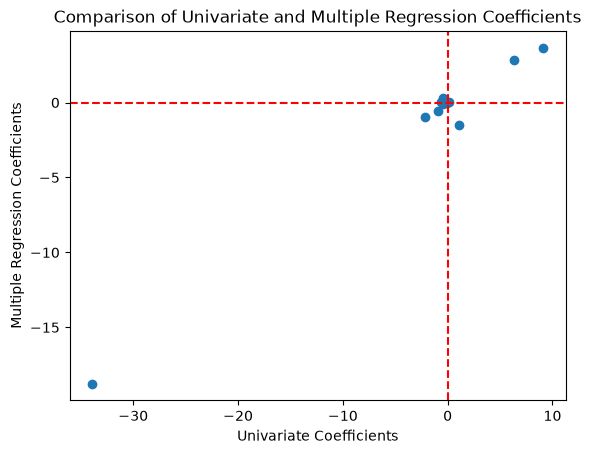

In [57]:
#(c) How do your results from (a) compare to your results from (b)? Create a plot displaying the univariate regression coefficients from 
#(a) on the x-axis, and the multiple regression coefficients
#(b) on the y-axis. That is, each predictor is displayed as a single point in the plot.
#Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate
#in the multiple linear regression model is shown on the y-axis.
univariate_results = {}
for var in predictors:
    x = sm.add_constant(boston[var])
    y = boston["medv"]
    model = sm.OLS(y, x).fit()
    univariate_results[var] = model

unvariate_coefs = [univariate_results[var].params[1] for var in predictors]
multiple_coefs = results.params[1:]
plt.scatter(unvariate_coefs, multiple_coefs)
plt.xlabel('Univariate Coefficients')
plt.ylabel('Multiple Regression Coefficients')
plt.title('Comparison of Univariate and Multiple Regression Coefficients')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [59]:
#(d) Is there evidence of non-linear association between any of the predictors and the response? 
#To answer this question, for each predictor X, fit a model of the form
#.0$$Y= \beta_0 + \beta_1X + β2X^2 + \beta_3X^3 + \epsilon.$$
non_linear_results = {}
for var in predictors:
    x = sm.add_constant(boston[var])
    x_poly = poly(x, degree=3)
    y = boston["medv"]
    X_poly = pd.DataFrame({
        "const": 1.0,
        var: boston[var].to_numpy(),
        f"{var}_sq": boston[var].to_numpy() ** 2,
        f"{var}_cub": boston[var].to_numpy() ** 3,
    })
    model = sm.OLS(y, X_poly).fit()
    non_linear_results[var] = model
    print(f"Results for predictor: {var}")
    print(model.summary())
    print("\n")

Results for predictor: crim
                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     46.57
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.45e-26
Time:                        15:22:51   Log-Likelihood:                -1778.1
No. Observations:                 506   AIC:                             3564.
Df Residuals:                     502   BIC:                             3581.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.1905   

/tmp/ipykernel_1453/3452302080.py:15: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y, X_poly).fit()


The quadratic and cubic terms are significant, there is evidence of non-linear association between crim and medv 